(streaming_dataset)=

# Out-of-core minibatch variational inference with DataLoader and Trainer

:::{post} June 2026
:tags: variational inference, minibatch, out-of-core, ADVI
:category: intermediate, how-to
:author: Yicheng (Ethan) Yang
:::

`pm.Minibatch` random-indexes an array that must be fully resident in RAM, so
minibatch variational inference only works on data that already fits in memory.
This notebook uses the streaming API in `pymc.variational.streaming`, which follows
the same structure as PyTorch's `torch.utils.data`:

* a {class}`~pymc.variational.streaming.DataLoader` batches (and optionally
  shuffles) an out-of-core source into fixed-size minibatches, holding only one
  batch in memory at a time. Here the source is a directory of Parquet shards read
  by {func}`~pymc.variational.streaming.parquet_source`.
* the model observes a `pm.Data` placeholder of one batch, not the whole array.
* a {class}`~pymc.variational.streaming.Trainer` drives ADVI, writing each
  minibatch into that placeholder with `set_data` every step. There are no callbacks.

The unbiased-gradient rescaling works exactly as in `pm.Minibatch`. The `DataLoader`
is sized, so `total_size=len(loader)` passes the dataset size `N` to the observed
distribution, and PyMC scales the minibatch log-likelihood by `N / batch_size`. The
one extra requirement is shuffling. A streaming source is only as well mixed as the
order it yields rows in, so pass `DataLoader(shuffle=True)` to shuffle through a
bounded buffer.

`N` is small here so the notebook runs in seconds. The streaming code is the same at
any size, and the last section shows what changes at scale.

In [1]:
import glob
import tempfile

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import pymc as pm

from pymc.variational.streaming import DataLoader, Trainer, parquet_source

RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")

## Put a dataset on disk and forget the array

We build a logistic-regression dataset, write it to Parquet shards, and delete the
in-memory table. From here the features only exist on disk. We keep `X` and `y`
around only to build the in-RAM `pm.Minibatch` baseline later; the streaming fit
never reads them.

In [2]:
N = 30_000
b_true = np.array([0.4, -1.2, 0.8, -0.5])  # intercept + 3 slopes

X = rng.normal(size=(N, 3))
p = 1 / (1 + np.exp(-(b_true[0] + X @ b_true[1:])))
y = (rng.random(N) < p).astype("float64")
table = np.column_stack([X, y]).astype("float64")

shard_dir = tempfile.mkdtemp(prefix="streaming_demo_")
for i, s in enumerate(range(0, N, 5_000)):
    block = table[s : s + 5_000]
    pq.write_table(
        pa.table({f"c{j}": block[:, j] for j in range(4)}),
        f"{shard_dir}/part_{i:03d}.parquet",
    )
del table
print(len(glob.glob(f"{shard_dir}/*.parquet")), "shards written")

6 shards written


## Stream minibatches off disk and fit with ADVI

`parquet_source` is an out-of-core {class}`~pymc.variational.streaming.IterableDataset`.
It reads one shard at a time and gets `n_rows` from the Parquet metadata without
scanning the data, so `total_size="auto"` resolves `N` for free. The `DataLoader`
batches and shuffles it into fixed-size minibatches. The model reads a
`pm.Data("batch", ...)` placeholder, the only data resident at any point, and the
`Trainer` writes each minibatch into it with `set_data`. There are no callbacks:
`total_size=len(loader)` triggers the `N / batch_size` rescaling and `Trainer.fit`
runs the loop.

In [3]:
batch_size = 1024
loader = DataLoader(
    parquet_source(shard_dir),
    batch_size=batch_size,
    sample_shape=(4,),  # 3 features + 1 observed column
    shuffle=True,  # the shards were written in order
    buffer_size=15_000,
    seed=0,
    total_size="auto",  # N from the Parquet metadata
)

with pm.Model() as model:
    b = pm.Normal("b", 0.0, 3.0, shape=4)
    batch = pm.Data("batch", np.zeros((batch_size, 4)))  # placeholder, the only data in RAM
    logit = b[0] + b[1] * batch[:, 0] + b[2] * batch[:, 1] + b[3] * batch[:, 2]
    pm.Bernoulli("y", logit_p=logit, observed=batch[:, 3], total_size=len(loader))

    approx = Trainer(
        method="advi",
        dataloader=loader,
        data_name="batch",
        obj_optimizer=pm.adam(learning_rate=0.008),
    ).fit(30_000, random_seed=RANDOM_SEED)
    idata_stream = approx.sample(1000)

Finished [100%]: Average Loss = 531.47


The negative-ELBO trace shows the fit converging while only ever holding a
`batch_size` buffer in memory:

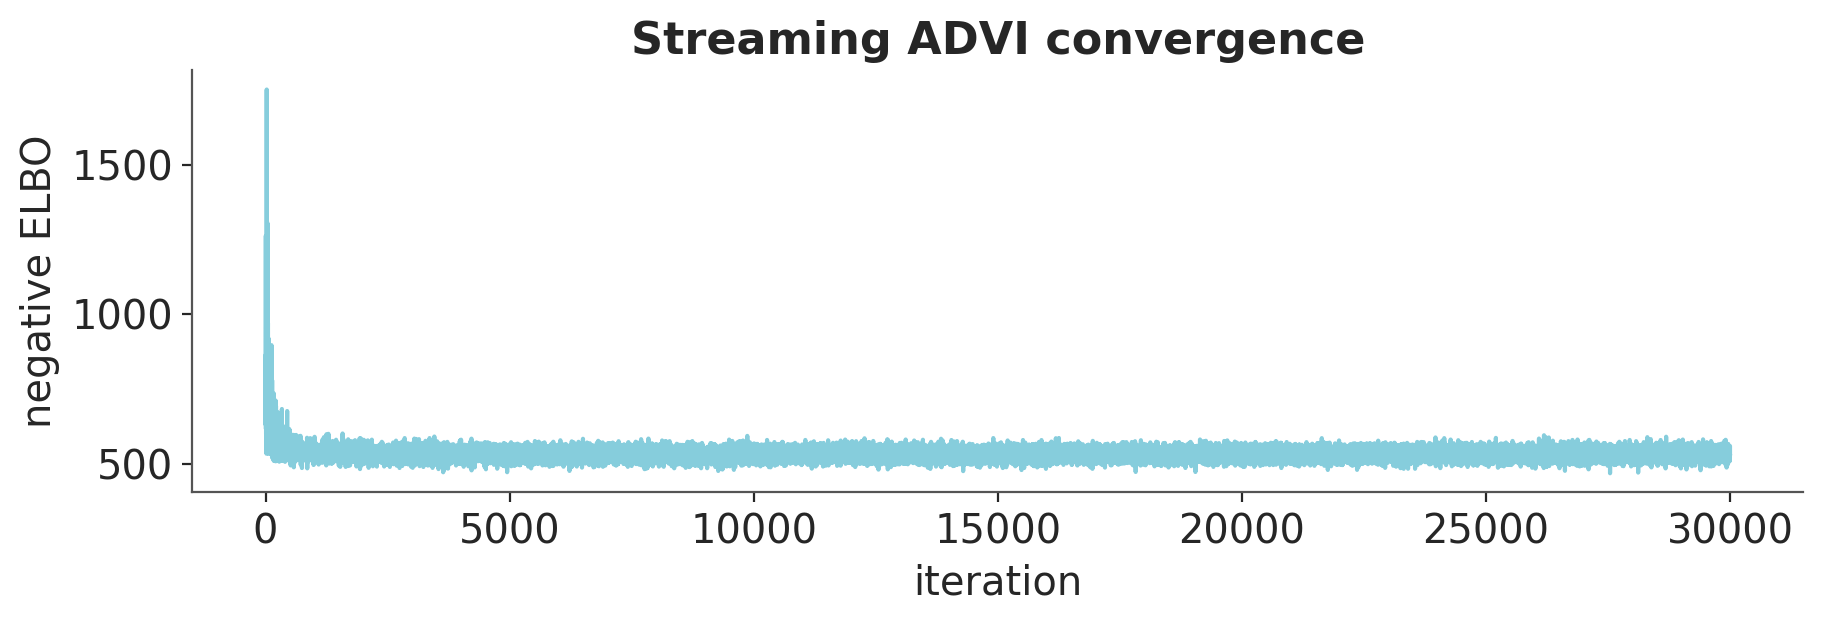

In [4]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(approx.hist, alpha=0.6)
ax.set(xlabel="iteration", ylabel="negative ELBO", title="Streaming ADVI convergence");

## The same posterior as in-RAM `pm.Minibatch`

For comparison, here is the usual fit that keeps the whole dataset in memory.
Streaming changes where the data lives, not the inference, so the two posteriors
land on top of each other. Both show ADVI's usual mild bias relative to the dashed
ground truth, but they agree with each other.

In [5]:
with pm.Model():
    b = pm.Normal("b", 0.0, 3.0, shape=4)
    xb, zb, sb, yb = pm.Minibatch(
        X[:, 0].copy(), X[:, 1].copy(), X[:, 2].copy(), y, batch_size=batch_size
    )
    pm.Bernoulli("y", logit_p=b[0] + b[1] * xb + b[2] * zb + b[3] * sb, observed=yb, total_size=N)
    approx_inram = pm.fit(
        30_000, method="advi", obj_optimizer=pm.adam(learning_rate=0.008), progressbar=False
    )
    idata_inram = approx_inram.sample(1000)

Finished [100%]: Average Loss = 531.98


/tmp/claude-501/ipykernel_88126/503280259.py:13: UserWarning: The figure layout has changed to tight
  fig.tight_layout();


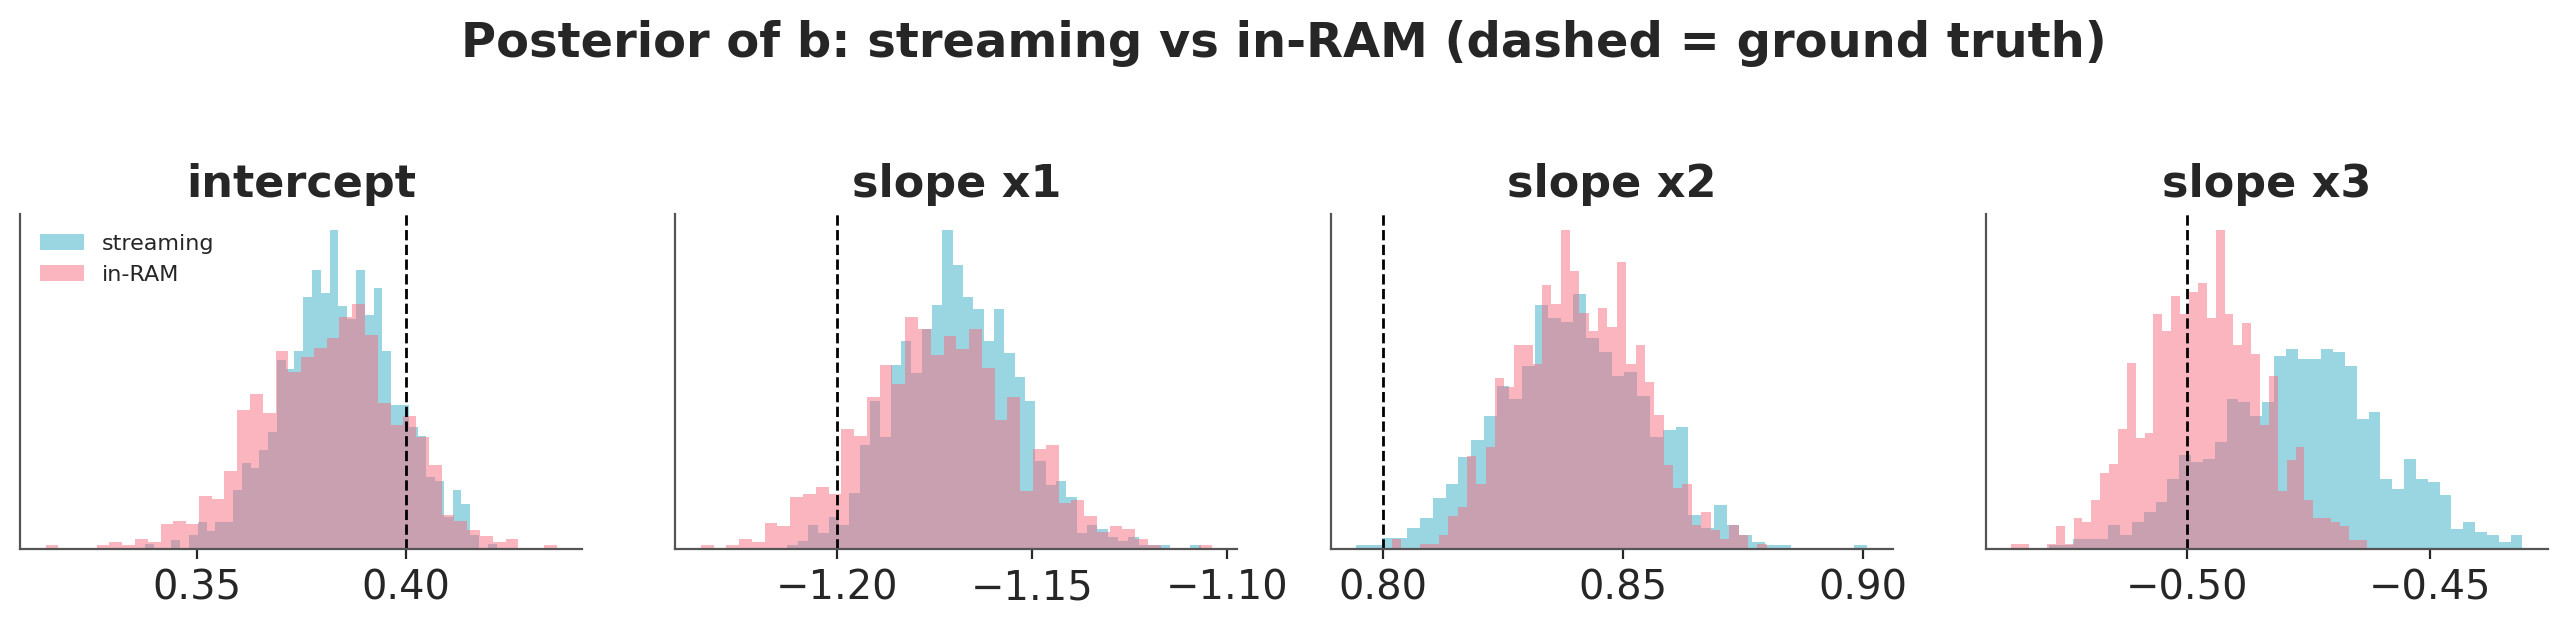

In [6]:
bs_stream = idata_stream.posterior["b"].values.reshape(-1, 4)
bs_inram = idata_inram.posterior["b"].values.reshape(-1, 4)
names = ["intercept", "slope x1", "slope x2", "slope x3"]

fig, axes = plt.subplots(1, 4, figsize=(13, 3))
for k, ax in enumerate(axes):
    ax.hist(bs_stream[:, k], bins=40, density=True, alpha=0.5, label="streaming")
    ax.hist(bs_inram[:, k], bins=40, density=True, alpha=0.5, label="in-RAM")
    ax.axvline(b_true[k], color="k", ls="--", lw=1)
    ax.set(title=names[k], yticks=[])
axes[0].legend(fontsize=8)
fig.suptitle("Posterior of b: streaming vs in-RAM (dashed = ground truth)", y=1.04)
fig.tight_layout();

## Memory usage

Both paths feed the same `batch_size` to ADVI, but `pm.Minibatch` keeps all `N`
rows resident, so its array grows linearly in `N`, while the streaming `DataLoader`
only holds one `batch_size` buffer. The dense `float64` design matrix dominates the
cost. The line below is its lower bound (`N * ncols * 8` bytes), not a measurement:

/tmp/claude-501/ipykernel_88126/2826343238.py:15: UserWarning: The figure layout has changed to tight
  fig.tight_layout();


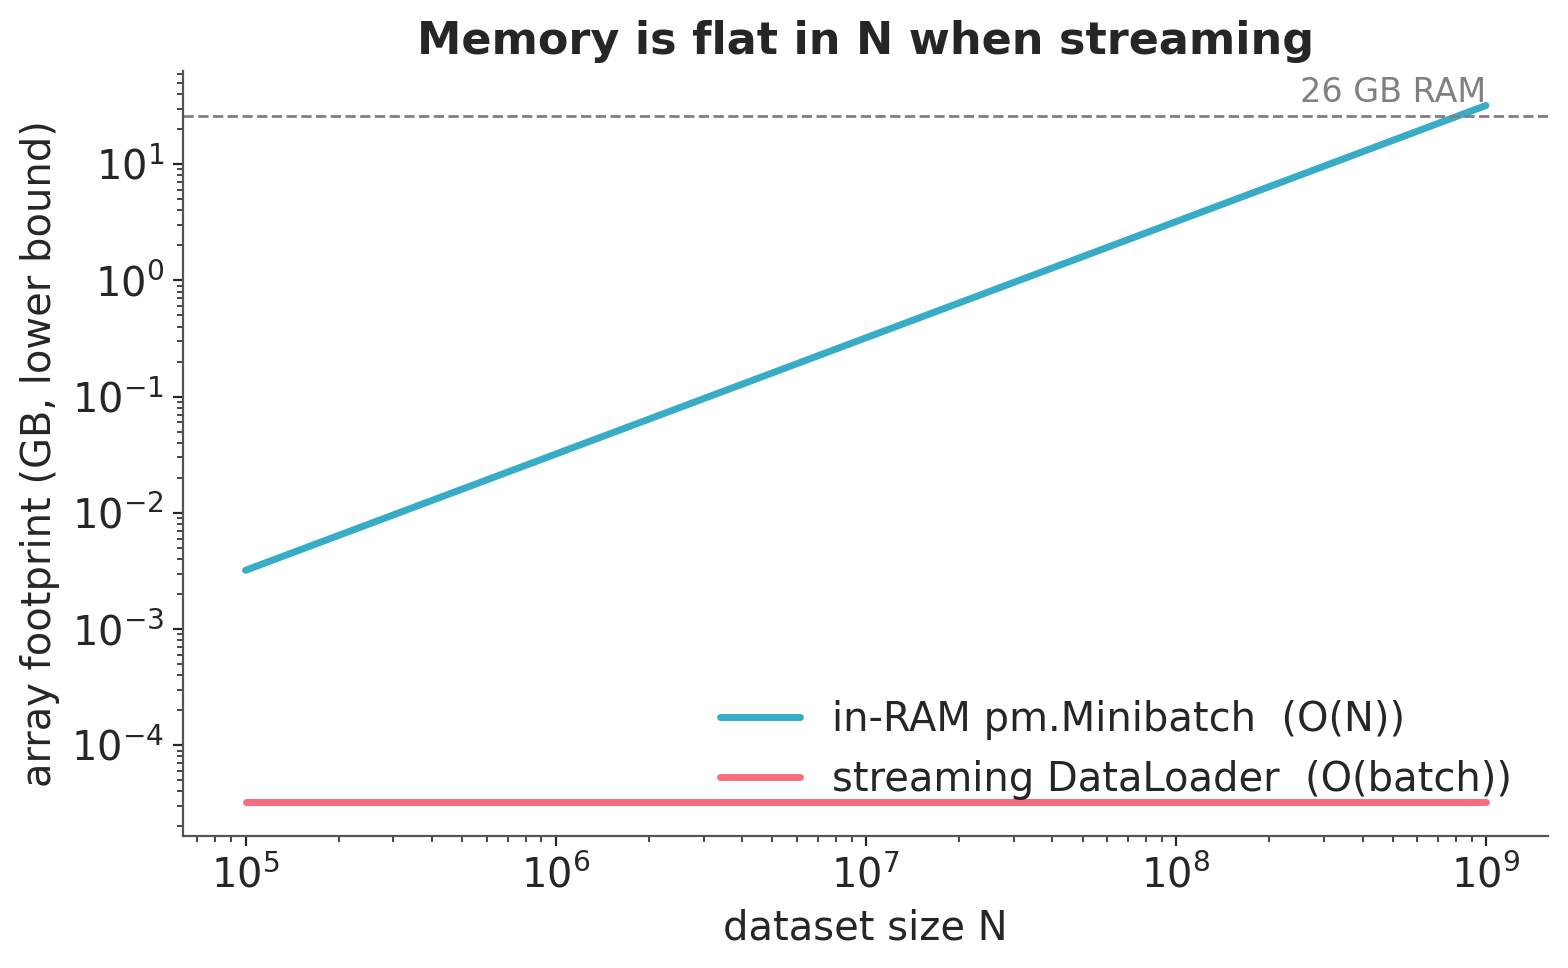

In [7]:
ncols = 4  # 3 features + observed
n_grid = np.logspace(5, 9, 50)
inram_gb = n_grid * ncols * 8 / 1e9  # whole dataset resident (array lower bound)
stream_gb = np.full_like(n_grid, batch_size * ncols * 8 / 1e9)  # just the buffer

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(n_grid, inram_gb, lw=2.5, label="in-RAM pm.Minibatch  (O(N))")
ax.loglog(n_grid, stream_gb, lw=2.5, label="streaming DataLoader  (O(batch))")
ax.axhline(26, color="0.5", ls="--", lw=1)
ax.text(n_grid[-1], 30, "26 GB RAM", color="0.5", ha="right", va="bottom")
ax.set_xlabel("dataset size N")
ax.set_ylabel("array footprint (GB, lower bound)")
ax.set_title("Memory is flat in N when streaming")
ax.legend(loc="lower right", framealpha=0.95)
fig.tight_layout();

That line is only the bare array. Actual peak RSS is higher, because of the
framework and PyTensor's resident copy, and it hits the RAM ceiling sooner. To get
the real number on public data, I measured peak memory on the
[Criteo 1TB Click Logs](https://huggingface.co/datasets/criteo/CriteoClickLogs), a
standard out-of-core learning benchmark, with the same logistic model (13 numeric
features plus the click label). Streaming through the `DataLoader` stayed flat at
about 0.7 GB across a sweep from 1M to 150M rows. The in-RAM `pm.Minibatch` baseline
rose linearly to 15.7 GB at 150M rows, about 21 times more, and extrapolates to
out-of-memory near 238M rows on a 26 GB machine. The two posteriors agree to
within ADVI noise (correlation 0.999 across all 14 coefficients). Criteo is
public, so anyone can rerun this.

## When to use it

* Use `pm.Minibatch` when the data fits in RAM: it is simpler and its random
  index gives perfectly i.i.d. minibatches for free.
* Use the streaming `DataLoader` and `Trainer` when it does not: it keeps memory
  flat in `N` by streaming from disk, with no callbacks to wire up. The one thing to
  watch is shuffling. Pass `shuffle=True`, or pre-shuffle on disk and interleave
  shards for strongly ordered data, since a bounded buffer over strongly ordered
  data only block-shuffles it and biases the posterior.

## Authors

* Authored by Yicheng (Ethan) Yang in June 2026 for the Google Summer of Code
  project *Streaming Variational Inference for Large Datasets* (PyMC / NumFOCUS).

## References

* Hoffman, M. D., Blei, D. M., Wang, C., & Paisley, J. (2013). Stochastic
  variational inference. *Journal of Machine Learning Research*, 14(1).
* Kucukelbir, A., Tran, D., Ranganath, R., Gelman, A., & Blei, D. M. (2017).
  Automatic differentiation variational inference. *JMLR*, 18(1).

In [8]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pytensor,pyarrow

Last updated: Wed, 10 Jun 2026

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.13.0

pytensor: 3.0.3
pyarrow : 24.0.0

arviz     : 1.1.0
matplotlib: 3.10.9
numpy     : 2.4.6
platform  : 1.0.8
pyarrow   : 24.0.0
pymc      : 6.0.1

Watermark: 2.6.0



:::{include} ../page_footer.md
:::